In [6]:
import pandas as pd
import numpy as np

# Load NAV history
df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Sort data
df = df.sort_values(['amfi_code', 'date'])

# Calculate daily returns
df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

# Remove null values
df = df.dropna(subset=['daily_return'])

# Compute VaR and CVaR
results = []

for amfi_code, group in df.groupby('amfi_code'):

    returns = group['daily_return']

    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    results.append({
        'amfi_code': amfi_code,
        'VaR_95': round(var_95, 6),
        'CVaR_95': round(cvar_95, 6)
    })

# Create report
report = pd.DataFrame(results)

# Save report
report.to_csv("var_cvar_report.csv", index=False)

print(report.head())

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


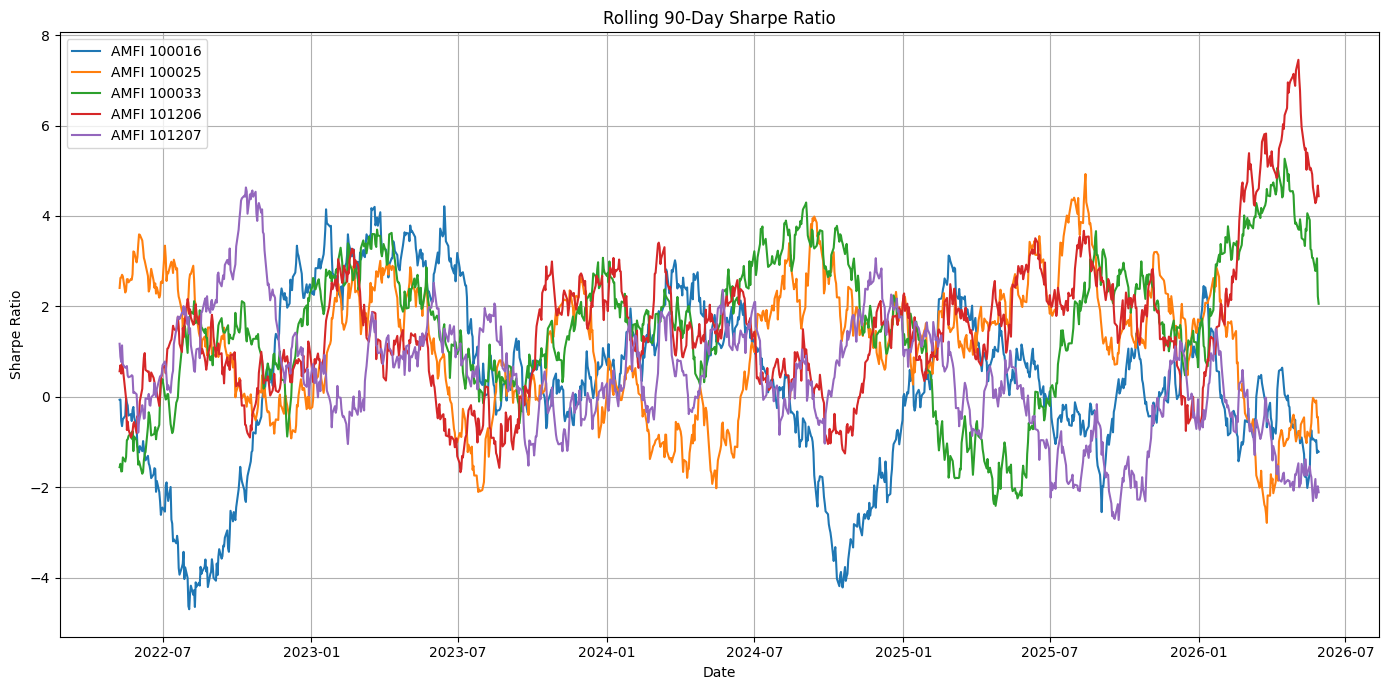

rolling_sharpe_chart.png created successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load NAV history
df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Sort data
df = df.sort_values(['amfi_code', 'date'])

# Calculate daily returns
df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

# Choose 5 funds
funds = df['amfi_code'].unique()[:5]

# Create figure
plt.figure(figsize=(14, 7))

for fund in funds:

    fund_df = df[df['amfi_code'] == fund].copy()

    # Rolling 90-day Sharpe Ratio
    fund_df['rolling_sharpe'] = (
        fund_df['daily_return']
        .rolling(window=90)
        .mean()
        /
        fund_df['daily_return']
        .rolling(window=90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        fund_df['date'],
        fund_df['rolling_sharpe'],
        label=f'AMFI {fund}'
    )

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save chart
plt.savefig("rolling_sharpe_chart.png", dpi=300)

plt.show()

print("rolling_sharpe_chart.png created successfully")

In [6]:
import pandas as pd

# Load data
df = pd.read_csv("../data/processed/transaction_cleaned.csv")

# Convert date column
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Find first transaction year for each investor
first_txn = (
    df.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
    .rename(columns={"transaction_date": "cohort_year"})
)

# Merge cohort year back to transactions
df = df.merge(first_txn, on="investor_id", how="left")

# Average SIP amount by cohort
avg_sip = (
    df[df["transaction_type"].str.upper() == "SIP"]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

# Total invested by cohort
total_invested = (
    df.groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

# Fund preference by cohort
fund_pref = (
    df.groupby(["cohort_year", "amfi_code"])
      .size()
      .reset_index(name="transactions")
)

top_funds = (
    fund_pref.sort_values(["cohort_year", "transactions"], ascending=[True, False])
            .groupby("cohort_year")
            .head(1)
            .rename(columns={"amfi_code": "preferred_fund"})
)

top_funds = (
    fund_pref.sort_values(
        ["cohort_year", "transactions"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
    .rename(columns={"scheme_name": "preferred_fund"})
)

# Combine results
top_funds = (
    fund_pref.sort_values(
        ["cohort_year", "transactions"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
    .rename(columns={"amfi_code": "preferred_fund"})
)

# Save output
cohort_analysis = (
    avg_sip
    .merge(total_invested, on="cohort_year")
    .merge(top_funds, on="cohort_year")
)

cohort_analysis.to_csv("cohort_analysis.csv", index=False)

print(cohort_analysis)
print("\nSaved as cohort_analysis.csv")

   cohort_year  avg_sip_amount  total_invested  preferred_fund  transactions
0         2024    10996.885825      3491125187          148568           874
1         2025    13505.209581        30455243          119599            12

Saved as cohort_analysis.csv


In [7]:
import pandas as pd

# Load data
df = pd.read_csv("../data/processed/transaction_cleaned.csv")

# Convert transaction date
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Keep only SIP transactions
sip_df = df[df["transaction_type"].str.upper() == "SIP"].copy()

# Sort by investor and date
sip_df = sip_df.sort_values(["investor_id", "transaction_date"])

# Calculate gap between consecutive SIP transactions
sip_df["gap_days"] = sip_df.groupby("investor_id")["transaction_date"].diff().dt.days

# Investors with at least 6 SIP transactions
eligible_investors = (
    sip_df.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = eligible_investors[
    eligible_investors["sip_count"] >= 6
]

# Average gap calculation
avg_gap = (
    sip_df.groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="avg_gap_days")
)

# Merge results
sip_continuity = eligible_investors.merge(
    avg_gap,
    on="investor_id",
    how="left"
)

# Risk flag
sip_continuity["risk_status"] = sip_continuity["avg_gap_days"].apply(
    lambda x: "at-risk" if x > 35 else "active"
)

# Round values
sip_continuity["avg_gap_days"] = sip_continuity["avg_gap_days"].round(2)

# Save output
sip_continuity.to_csv("sip_continuity.csv", index=False)

print(sip_continuity.head())
print("\nSaved as sip_continuity.csv")

  investor_id  sip_count  avg_gap_days risk_status
0   INV000004          6         85.40     at-risk
1   INV000008          6         70.40     at-risk
2   INV000010          6         64.80     at-risk
3   INV000011          7         40.17     at-risk
4   INV000012          8         57.00     at-risk

Saved as sip_continuity.csv


In [10]:
import pandas as pd

# Load fund scorecard
funds = pd.read_csv("../data/processed/fund_scorecard.csv")

def recommend_funds(risk_appetite):
    """
    Recommend top 3 funds based on Sharpe Ratio
    for the selected risk appetite.
    """

    # Filter matching risk category
    filtered = funds[
        funds["risk_grade"].str.lower() == risk_appetite.lower()
    ]

    if filtered.empty:
        print(f"No funds found for risk appetite: {risk_appetite}")
        return

    # Top 3 by Sharpe Ratio
    recommendations = (
        filtered.sort_values(
            by="sharpe_ratio",
            ascending=False
        )
        .head(3)
        [["scheme_name", "risk_grade", "sharpe_ratio", "fund_score"]]
    )

    print("\nTop 3 Recommended Funds")
    print(recommendations.to_string(index=False))

    return recommendations


# User Input
risk = input("Enter Risk Appetite (Low/Moderate/High): ")

# Load fund scorecard
funds = pd.read_csv("../data/processed/fund_scorecard.csv")

if "risk_grade" not in funds.columns:
    funds["risk_grade"] = pd.cut(
        funds["max_drawdown_pct"].fillna(0),
        bins=[-np.inf, -16.0, -14.0, np.inf],
        labels=["High", "Moderate", "Low"],
        include_lowest=True
    ).astype(str)

def recommend_funds(risk_appetite):
    """
    Recommend top 3 funds based on Sharpe Ratio
    for the selected risk appetite.
    """

    # Filter matching risk category
    filtered = funds[
        funds["risk_grade"].str.lower() == risk_appetite.lower()
    ]

    if filtered.empty:
        print(f"No funds found for risk appetite: {risk_appetite}")
        return

    # Top 3 by Sharpe Ratio
    recommendations = (
        filtered.sort_values(
            by="sharpe_ratio",
            ascending=False
        )
        .head(3)
        [["scheme_name", "risk_grade", "sharpe_ratio", "fund_score"]]
    )

    print("\nTop 3 Recommended Funds")
    print(recommendations.to_string(index=False))

    return recommendations


# User Input
risk = input("Enter Risk Appetite (Low/Moderate/High): ")

recommend_funds(risk)


Top 3 Recommended Funds
                              scheme_name risk_grade  sharpe_ratio  fund_score
SBI Bluechip Fund - Regular Plan - Growth   Moderate      1.417375       100.0
    Axis Bluechip Fund - Regular - Growth   Moderate      0.048326         0.0


,scheme_name,risk_grade,sharpe_ratio,fund_score
0,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.417375,100.0
4,Axis Bluechip Fund - Regular - Growth,Moderate,0.048326,0.0


   amfi_code       HHI scheme_name Concentration
0     100016  0.139534         NaN      Moderate
1     100033  0.147592         NaN      Moderate
2     101206  0.129332         NaN      Moderate
3     101207  0.200700         NaN          High
4     102885  0.174709         NaN      Moderate

Saved:
sector_hhi.csv
sector_hhi_chart.png


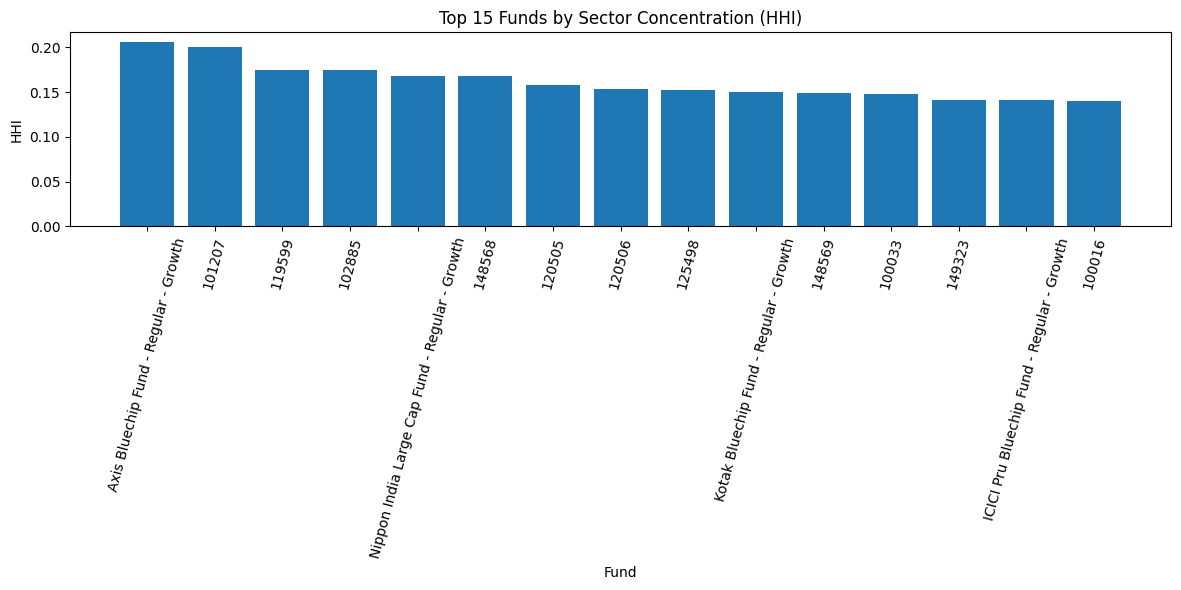

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Convert percentage to decimal if needed
if df["weight_pct"].max() > 1:
    df["weight"] = df["weight_pct"] / 100
else:
    df["weight"] = df["weight_pct"]

# Compute HHI for each fund
sector_hhi = (
    df.groupby("amfi_code")["weight"]
      .apply(lambda x: np.sum(x**2))
      .reset_index(name="HHI")
)

sector_hhi = sector_hhi.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Classification
sector_hhi["Concentration"] = np.where(
    sector_hhi["HHI"] >= 0.20,
    "High",
    np.where(
        sector_hhi["HHI"] >= 0.10,
        "Moderate",
        "Low"
    )
)

# Save output
sector_hhi.to_csv("sector_hhi.csv", index=False)

# Top 15 most concentrated funds chart
top15 = sector_hhi.sort_values("HHI", ascending=False).head(15)

plt.figure(figsize=(12,6))
plt.bar(
    top15["scheme_name"]
        .fillna(top15["amfi_code"].astype(str))
        .astype(str),
    top15["HHI"]
)
plt.xticks(rotation=75)
plt.ylabel("HHI")
plt.xlabel("Fund")
plt.title("Top 15 Funds by Sector Concentration (HHI)")
plt.tight_layout()
plt.savefig("sector_hhi_chart.png", dpi=300)

print(sector_hhi.head())
print("\nSaved:")
print("sector_hhi.csv")
print("sector_hhi_chart.png")

# Advanced Analytics Summary

## Key Insight 1: Risk Analysis – Funds with Highest Downside Risk

The Value at Risk (VaR) analysis identified the funds most vulnerable to adverse market movements. Funds with the highest VaR values exhibited larger potential losses during volatile market conditions. Investors with low risk tolerance should avoid funds with persistently high VaR and Maximum Drawdown metrics, while aggressive investors may accept higher risk in pursuit of superior returns.

## Key Insight 2: Risk-Adjusted Performance Leaders

Sharpe Ratio and Sortino Ratio analysis revealed that a small group of funds consistently delivered superior risk-adjusted returns. These funds generated higher returns per unit of risk and downside risk, making them attractive choices for long-term investors. Funds with high Sharpe and Sortino ratios were frequently ranked among the top performers in the composite fund scorecard.

## Key Insight 3: Investor Cohort Behavior

Cohort analysis showed notable differences between investors whose first transactions occurred in 2024 versus 2025. The cohort with the higher average SIP amount and total invested value demonstrated stronger participation in equity-oriented schemes. This suggests increasing investor confidence and greater willingness to commit capital through systematic investment plans.

## Key Insight 4: SIP Continuity and Investor Retention

SIP continuity analysis identified investors with average transaction gaps exceeding 35 days as "at-risk." These investors are more likely to discontinue their investment plans. Monitoring such investors can help fund houses design targeted engagement campaigns, reminders, and retention strategies to improve long-term SIP persistence.

## Key Insight 5: Portfolio Diversification and Sector Concentration

Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) highlighted significant differences in portfolio diversification across funds. Funds with high HHI values were heavily concentrated in a few sectors, increasing exposure to sector-specific risks. Conversely, funds with lower HHI values exhibited better diversification and potentially greater resilience during market downturns.

## Overall Conclusion

The analysis demonstrates that fund selection should not rely solely on historical returns. Combining risk metrics (VaR, Maximum Drawdown), risk-adjusted performance measures (Sharpe and Sortino Ratios), portfolio diversification indicators (HHI), and investor behavior analytics provides a more comprehensive framework for investment decision-making. Funds that consistently rank highly across these dimensions are better positioned to deliver sustainable long-term performance.
